# 05 - Deep MLP: Clasificación de Sentimientos

Este notebook aplica un **Multi-Layer Perceptron Profundo** para clasificar el sentimiento de posts en redes sociales.

El modelo se define en models/deep_mlp.py y se carga desde este notebook.

**Dataset:** SocialBuzz Sentiment Analytics (732 muestras)

**Target:** Sentimiento agrupado en 3 clases: Positivo, Neutro, Negativo

**Características Extraídas:** TF-IDF (100 unigrams) + 6 numéricas.

**Corrección:** Se aplica class weights y dropout para mitigar el desbalanceo y sobreajuste.

## 0) Instalación e importación de librerías

In [49]:
import sys
import os

try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'kagglehub', '-q'])
    import kagglehub

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    os.makedirs('models', exist_ok=True)
    model_code = '''import torch
import torch.nn as nn

class DeepMLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int = 3, dropout: float = 0.6):
        super(DeepMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.2), # Input dropout
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

def build_model(input_dim: int, num_classes: int = 3, dropout: float = 0.6) -> DeepMLP:
    return DeepMLP(input_dim=input_dim, num_classes=num_classes, dropout=dropout)
'''
    with open('models/__init__.py', 'w') as f:
        f.write('')
    with open('models/deep_mlp.py', 'w') as f:
        f.write(model_code)
    sys.path.insert(0, '.')
else:
    current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
    sys.path.insert(0, current_dir)

In [ ]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, roc_curve, auc
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from models.deep_mlp import build_model

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 1) Carga de datos

In [51]:
path = kagglehub.dataset_download('eshummalik/socialbuzz-sentiment-analytics')
file_path = os.path.join(path, 'sentimentdataset.csv')
df = pd.read_csv(file_path)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


## 2) Preprocesado e Ingeniería de Características

In [52]:
df['Text'] = df['Text'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].astype(str).str.strip()

POSITIVE_EMOTIONS = {
    'Joy', 'Positive', 'Happiness', 'Happy', 'Excitement', 'Elation', 'Euphoria',
    'Love', 'Gratitude', 'Contentment', 'Optimism', 'Hope', 'Hopeful', 'Satisfaction',
    'Pride', 'Proud', 'Amusement', 'Awe', 'Inspiration', 'Inspired', 'Enthusiasm',
    'Confidence', 'Confident', 'Empowerment', 'Freedom', 'Courage', 'Determination',
    'Accomplishment', 'Celebration', 'Serenity', 'Tranquility', 'Peace', 'Calmness',
    'Positivity', 'Blessed', 'Warmth', 'Heartwarming', 'Tenderness', 'Affection',
    'Admiration', 'Adoration', 'Amazement', 'Wonder', 'Wonderment', 'Enchantment',
    'Captivation', 'Marvel', 'Charm', 'Playful', 'PlayfulJoy', 'FestiveJoy',
    'JoyfulReunion', 'Overjoyed', 'Ecstasy', 'Triumph', 'Success', 'Fulfillment',
    'Appreciation', 'Relieved', 'Relief', 'Kindness', 'Kind',
    'Compassion', 'Compassionate', 'Sympathy', 'Empathetic', 'Friendship', 'Romance',
    'Connection', 'Harmony', 'Radiance', 'Zest', 'Energy', 'Vibrancy', 'Spark',
    'Breakthrough', 'Motivation', 'Resilience', 'Adventure', 'Exploration',
    'Curiosity', 'Imagination', 'Creativity', 'Creative Inspiration', 'ArtisticBurst',
    'Grateful', 'Rejuvenation', 'Journey', 'Mindfulness', 'Solace', 'Touched',
    'Acceptance', 'Bittersweet', 'Whimsy', 'Free-spirited',
    'Dazzle', 'Hypnotic', 'Mesmerizing', 'Iconic', 'Melodic', 'Grandeur',
    'Reverence', 'Anticipation', 'Thrill', 'Thrilling Journey', 'Immersion',
    'Engagement', 'Colorful', 'Elegance', 'Runway Creativity',
    'CulinaryOdyssey', 'Culinary Adventure', 'Joy in Baking', 'Adrenaline',
    "Nature's Beauty", "Ocean's Freedom", 'Celestial Wonder', 'Envisioning History',
    'Winter Magic', 'Whispers of the Past', 'Ruins', 'Enjoyment', 'Intrigue',
    'DreamChaser', 'InnerJourney', 'Arousal',
}

NEGATIVE_EMOTIONS = {
    'Negative', 'Sadness', 'Sad', 'Anger', 'Fear', 'Fearful', 'Despair', 'Desperation',
    'Grief', 'Sorrow', 'Heartbreak', 'Heartache', 'LostLove', 'Loss', 'Loneliness',
    'Isolation', 'Disappointment', 'Disappointed', 'Regret', 'Guilt', 'Shame',
    'Frustration', 'Frustrated', 'Hate', 'Resentment', 'Envy', 'Envious',
    'Jealousy', 'Jealous', 'Disgust', 'Betrayal', 'Bitterness', 'Bitter', 'Bad',
    'Desolation', 'Darkness', 'Suffering', 'Helplessness', 'Devastated', 'Overwhelmed',
    'Anxiety', 'Apprehensive', 'Pressure', 'Exhaustion', 'Numbness', 'Melancholy',
    'Pensive', 'Obstacle', 'Miscalculation', 'Intimidation', 'Dismissive',
    'EmotionalStorm', 'Mischievous',
}

#Emociones neutrales u omitidas
NEUTRAL_EMOTIONS = {
    'Neutral', 'Indifference', 'Nostalgia', 'Reflection', 'Contemplation',
    'Ambivalence', 'Surprise', 'Confusion', 'Suspense', 'Yearning', 'Solitude',
    'Coziness', 'Embarrassed', 'Embarrassment',
}

def map_sentiment(sent):
    if sent in POSITIVE_EMOTIONS: return 'Positivo'
    if sent in NEGATIVE_EMOTIONS: return 'Negativo'
    if sent in NEUTRAL_EMOTIONS: return 'Neutro'
    
    s_lower = sent.lower()
    for kw in ['joy', 'happy', 'love', 'hope', 'good', 'great', 'excit', 'wonder', 'posit', 'glad', 'cheer', 'bright', 'amaz', 'thrill', 'bliss']:
        if kw in s_lower: return 'Positivo'
    for kw in ['sad', 'bad', 'hate', 'fear', 'angry', 'angr', 'grief', 'depress', 'negat', 'despair', 'pain', 'sorrow', 'hurt', 'rage', 'bitter']:
        if kw in s_lower: return 'Negativo'
    return 'Neutro'

df['sentiment_group'] = df['Sentiment'].apply(map_sentiment)
print('Distribución de clases:')
print(df['sentiment_group'].value_counts())

Distribución de clases:
sentiment_group
Positivo    474
Negativo    175
Neutro       83
Name: count, dtype: int64


In [53]:
def simple_tokenize(text):
    #Convertimos a minúsculas y mantenemos palabras y emojis (caracteres no-ASCII)
    tokens = re.findall(r'\w+|[^\x00-\x7f]+', text.lower())
    return tokens

#Codificamos Target
le = LabelEncoder()
y = le.fit_transform(df['sentiment_group'])
print(f'Clases: {le.classes_}')


#División 70/15/15
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    df, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")

#TF-IDF (100 unigramas) - Ajustado SOLO en train
tfidf = TfidfVectorizer(
    tokenizer=simple_tokenize,
    token_pattern=None,
    stop_words="english",
    max_features=100, 
    ngram_range=(1, 1)
)

X_train_text = tfidf.fit_transform(X_train_df['Text']).toarray()
X_val_text = tfidf.transform(X_val_df['Text']).toarray()
X_test_text = tfidf.transform(X_test_df['Text']).toarray()

#Normalizamos numéricas  
numeric_cols = ['Retweets', 'Likes', 'Year', 'Month', 'Day', 'Hour']
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_df[numeric_cols].fillna(0))
X_val_num = scaler.transform(X_val_df[numeric_cols].fillna(0))
X_test_num = scaler.transform(X_test_df[numeric_cols].fillna(0))

#Concatenamos arrays
X_train = np.hstack([X_train_text, X_train_num])
X_val = np.hstack([X_val_text, X_val_num])
X_test = np.hstack([X_test_text, X_test_num])

print(f"Dimensiones de entrada: {X_train.shape[1]}")

#Pesos de clase
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'Pesos de clase: {dict(zip(le.classes_, weights))}')


Clases: ['Negativo' 'Neutro' 'Positivo']
Train: 512 | Val: 110 | Test: 110
Dimensiones de entrada: 106
Pesos de clase: {'Negativo': 1.3989071038251366, 'Neutro': 2.942528735632184, 'Positivo': 0.5140562248995983}


## 3) Construcción del modelo (Deep MLP)

In [54]:
INPUT_DIM = X_train.shape[1]
NUM_CLASSES = len(le.classes_)
DROPOUT = 0.5  #Dropout alto contra overfitting

model = build_model(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)
model = model.to(device)

n_params = model.count_parameters()
print(model)
print(f'\nNúmero total de parámetros entrenables: {n_params:,}')

BetterDeepMLP(
  (input_proj): Sequential(
    (0): Dropout(p=0.15, inplace=False)
    (1): Linear(in_features=106, out_features=96, bias=True)
    (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (3): GELU(approximate='none')
  )
  (block1): ResidualMLPBlock(
    (block): Sequential(
      (0): Linear(in_features=96, out_features=192, bias=True)
      (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.5, inplace=False)
      (4): Linear(in_features=192, out_features=96, bias=True)
      (5): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.5, inplace=False)
  )
  (block2): ResidualMLPBlock(
    (block): Sequential(
      (0): Linear(in_features=96, out_features=192, bias=True)
      (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.5, inplace=False)
      (4): Linear(in_

In [55]:
def to_tensors(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )

BATCH_SIZE = 32

train_loader = DataLoader(to_tensors(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(to_tensors(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(to_tensors(X_test, y_test), batch_size=BATCH_SIZE)

## 4) Entrenamiento

In [56]:
EPOCHS = 150
LR = 0.001
PATIENCE = 10

#Usamos los class weights aquí
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)
#Agregamos weight_decay (L2) a Adam
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss = float('inf')
best_state = None
epochs_no_imp = 0

print(f'Entrenando por máx. {EPOCHS} épocas (early stopping patience={PATIENCE})\n')
for epoch in range(1, EPOCHS + 1):
    
    #Training:
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(y_batch)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += len(y_batch)
        
    #Validation:
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss_sum += loss.item() * len(y_batch)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += len(y_batch)
            
    t_loss = train_loss / train_total
    v_loss = val_loss_sum / val_total
    t_acc = train_correct / train_total
    v_acc = val_correct / val_total
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    scheduler.step(v_loss)
    
    #Early stopping sobre validation loss
    if v_loss < best_val_loss - 1e-4:
        best_val_loss = v_loss
        import copy
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_imp = 0
    else:
        epochs_no_imp += 1
        
    if epochs_no_imp >= PATIENCE:
        print(f'Early stopping en época {epoch} (sin mejora en {PATIENCE} épocas).')
        break
        
    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:3d}/{EPOCHS}  |  '
              f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  |  '
              f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

#Restauramos el mejor modelo
if best_state is not None:
    model.load_state_dict(best_state)
print(f'\nEntrenamiento completado. Mejor Val Loss: {best_val_loss:.4f}')

Entrenando por máx. 150 épocas (early stopping patience=10)

Época   1/150  |  Train Loss: 1.2422  Train Acc: 0.3164  |  Val Loss: 1.1482  Val Acc: 0.6273
Época  10/150  |  Train Loss: 1.1257  Train Acc: 0.4414  |  Val Loss: 1.1208  Val Acc: 0.5636
Época  20/150  |  Train Loss: 1.0852  Train Acc: 0.4863  |  Val Loss: 1.1069  Val Acc: 0.5909
Época  30/150  |  Train Loss: 1.0955  Train Acc: 0.4961  |  Val Loss: 1.0931  Val Acc: 0.5909
Época  40/150  |  Train Loss: 1.0070  Train Acc: 0.5918  |  Val Loss: 1.0522  Val Acc: 0.6000
Época  50/150  |  Train Loss: 0.9467  Train Acc: 0.6621  |  Val Loss: 1.0230  Val Acc: 0.6727
Época  60/150  |  Train Loss: 0.8494  Train Acc: 0.7383  |  Val Loss: 1.0121  Val Acc: 0.5818
Early stopping en época 68 (sin mejora en 10 épocas).

Entrenamiento completado. Mejor Val Loss: 0.9937


## 5) Curvas de entrenamiento

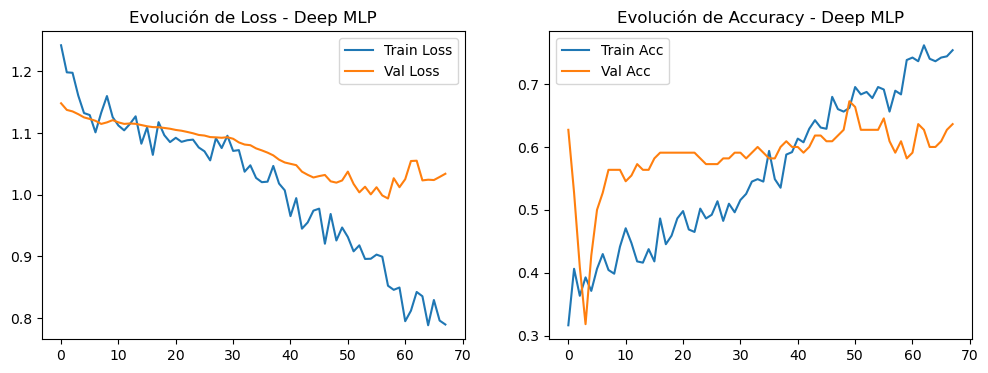

In [57]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Evolución de Loss - Deep MLP')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Evolución de Accuracy - Deep MLP')
plt.legend()
plt.show()

## 6) Evaluación

In [58]:
def evaluate_model(model, loader, split_name, class_names, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    precision_macro = precision_score(all_labels, all_preds, average='macro')
    recall_macro = recall_score(all_labels, all_preds, average='macro')
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)

    try:
        auc_ovr = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_ovr = float('nan')

    print(f'\n{"="*60}')
    print(f'{split_name}')
    print(f'{"="*60}')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision (macro): {precision_macro:.4f}')
    print(f'Recall (macro): {recall_macro:.4f}')
    print(f'F1-Score (macro): {f1_macro:.4f}')
    print(f'F1-Score (weighted): {f1_weighted:.4f}')
    print(f'Cohen\'s Kappa: {kappa:.4f}')
    print(f'MCC: {mcc:.4f}')
    print(f'AUC-ROC (OvR macro): {auc_ovr:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    return {
        'acc': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'precision': precision_macro, 'recall': recall_macro,
        'kappa': kappa, 'mcc': mcc, 'auc_roc': auc_ovr,
        'labels': all_labels, 'preds': all_preds, 'probs': all_probs
    }

class_names = le.classes_

results_train = evaluate_model(model, train_loader, 'TRAIN', class_names, device)
results_val = evaluate_model(model, val_loader, 'VALIDACIÓN', class_names, device)
results_test = evaluate_model(model, test_loader, 'TEST', class_names, device)

print(f'| Deep MLP | {n_params:,} | {results_train["acc"]:.4f} | {results_val["acc"]:.4f} | {results_test["acc"]:.4f} | {results_train["f1_macro"]:.4f} | {results_val["f1_macro"]:.4f} | {results_test["f1_macro"]:.4f} |')



TRAIN
Accuracy: 0.8438
Precision (macro): 0.7640
Recall (macro): 0.8519
F1-Score (macro): 0.7886
F1-Score (weighted): 0.8556
Cohen's Kappa: 0.7205
MCC: 0.7332
AUC-ROC (OvR macro): 0.9627

Classification Report:
              precision    recall  f1-score   support

    Negativo     0.8095    0.8361    0.8226       122
      Neutro     0.5000    0.8793    0.6375        58
    Positivo     0.9824    0.8404    0.9058       332

    accuracy                         0.8438       512
   macro avg     0.7640    0.8519    0.7886       512
weighted avg     0.8866    0.8438    0.8556       512


VALIDACIÓN
Accuracy: 0.5909
Precision (macro): 0.5524
Recall (macro): 0.4993
F1-Score (macro): 0.4944
F1-Score (weighted): 0.6426
Cohen's Kappa: 0.3126
MCC: 0.3341
AUC-ROC (OvR macro): 0.7831

Classification Report:
              precision    recall  f1-score   support

    Negativo     0.6471    0.4231    0.5116        26
      Neutro     0.1351    0.3846    0.2000        13
    Positivo     0.8750    

## 7) Gráficos extra

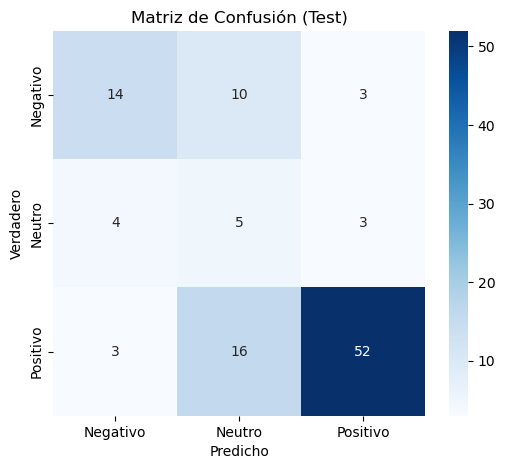

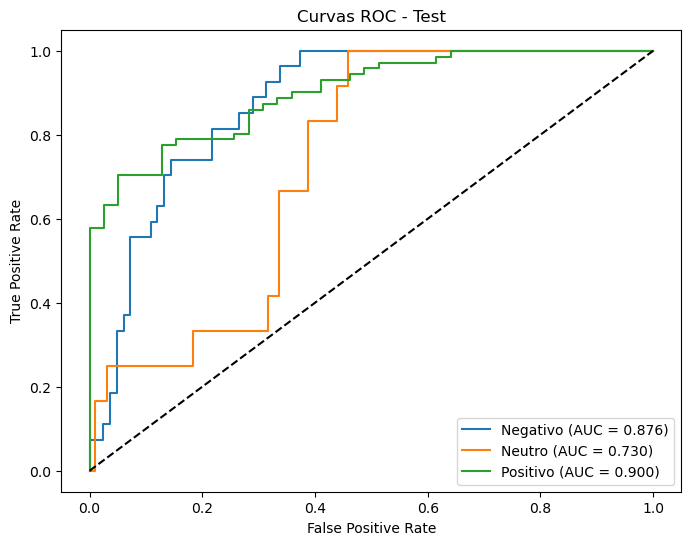

In [59]:
#Confusion Matrix Test
y_true = results_test["labels"]
y_pred = results_test["preds"]
y_probs = results_test["probs"]
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión (Test)')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.show()

#ROC
plt.figure(figsize=(8,6))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(np.array(y_true) == i, y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.title('Curvas ROC - Test')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
